In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025-selected-columns.csv')
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88


In [7]:
print(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
dtypes: float64(2), int64(6), object(2)
memory usage: 206.4+ KB
None


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000


### Check for Missing Values and Duplicates

In [8]:
print('Missing values per column:')
display(df.isnull().sum())

print('\nNumber of duplicate rows:')
display(df.duplicated().sum())

Missing values per column:


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0



Number of duplicate rows:


np.int64(0)

### Data Visualization: Deliveries and Production Trends

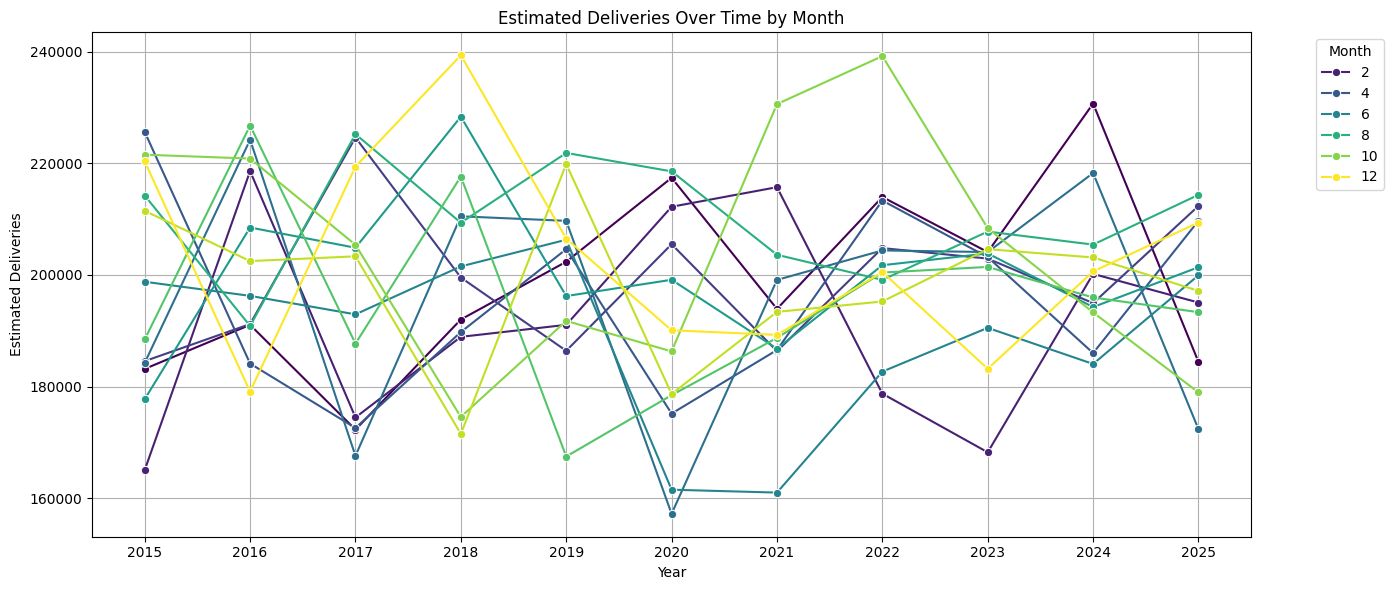

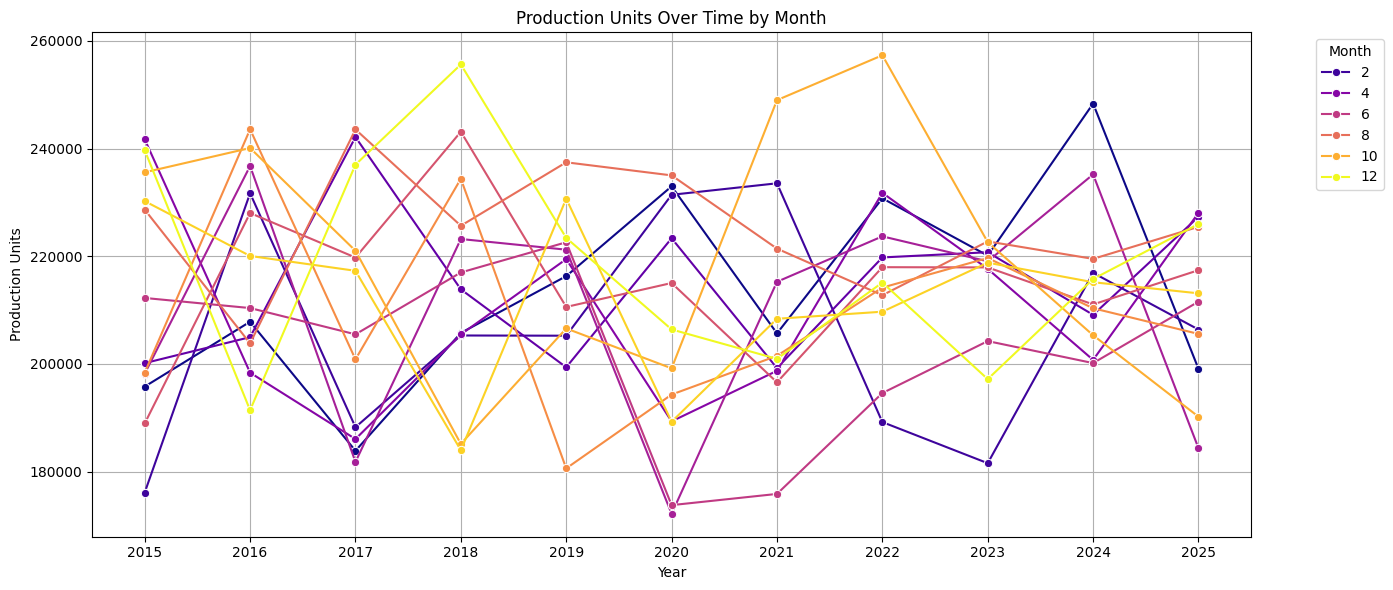

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.lineplot(data=df.groupby(['Year', 'Month'])[['Estimated_Deliveries', 'Production_Units']].sum().reset_index(), x='Year', y='Estimated_Deliveries', hue='Month', marker='o', palette='viridis')
plt.title('Estimated Deliveries Over Time by Month')
plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')
plt.xticks(df['Year'].unique())
plt.grid(True)
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df.groupby(['Year', 'Month'])[['Estimated_Deliveries', 'Production_Units']].sum().reset_index(), x='Year', y='Production_Units', hue='Month', marker='o', palette='plasma')
plt.title('Production Units Over Time by Month')
plt.xlabel('Year')
plt.ylabel('Production Units')
plt.xticks(df['Year'].unique())
plt.grid(True)
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Regional and Model Analysis

/tmp/ipykernel_1755/878566465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('Region')['Estimated_Deliveries'].sum().reset_index(), x='Region', y='Estimated_Deliveries', palette='coolwarm')


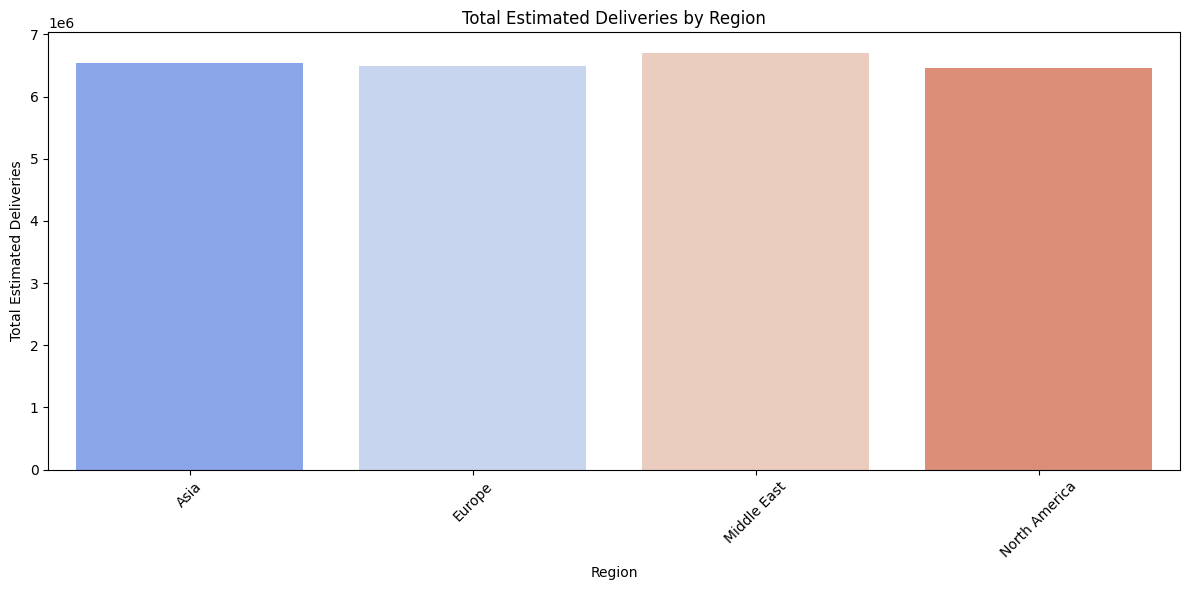

/tmp/ipykernel_1755/878566465.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('Model')['Estimated_Deliveries'].sum().reset_index(), x='Model', y='Estimated_Deliveries', palette='magma')


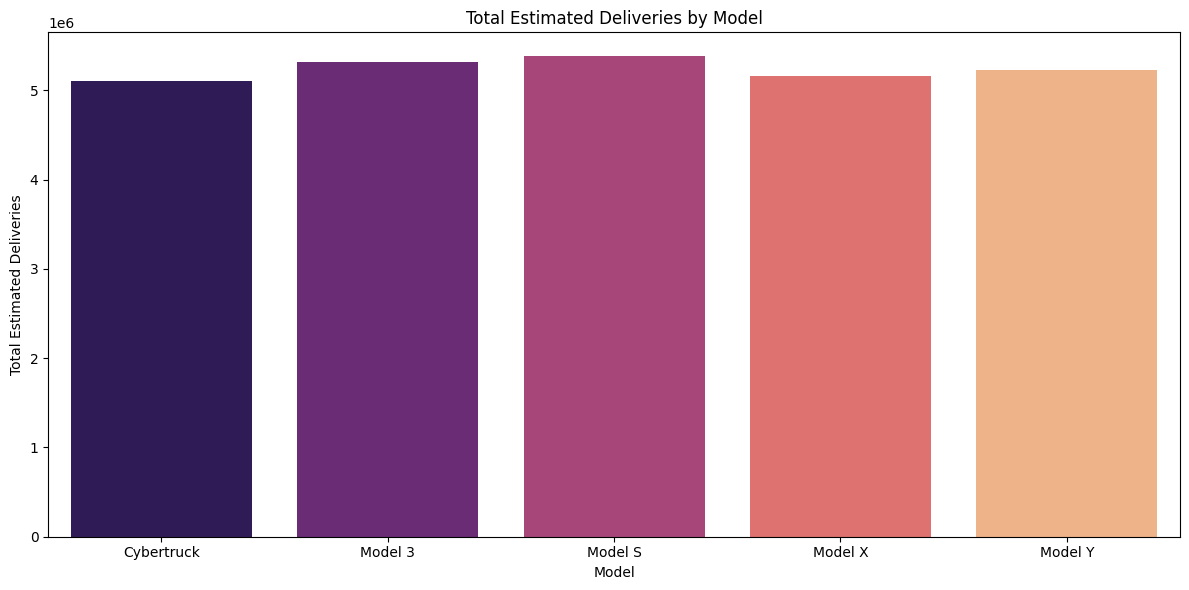

In [10]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df.groupby('Region')['Estimated_Deliveries'].sum().reset_index(), x='Region', y='Estimated_Deliveries', palette='coolwarm')
plt.title('Total Estimated Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Total Estimated Deliveries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df.groupby('Model')['Estimated_Deliveries'].sum().reset_index(), x='Model', y='Estimated_Deliveries', palette='magma')
plt.title('Total Estimated Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Total Estimated Deliveries')
plt.tight_layout()
plt.show()

### Correlation Analysis of Numerical Features

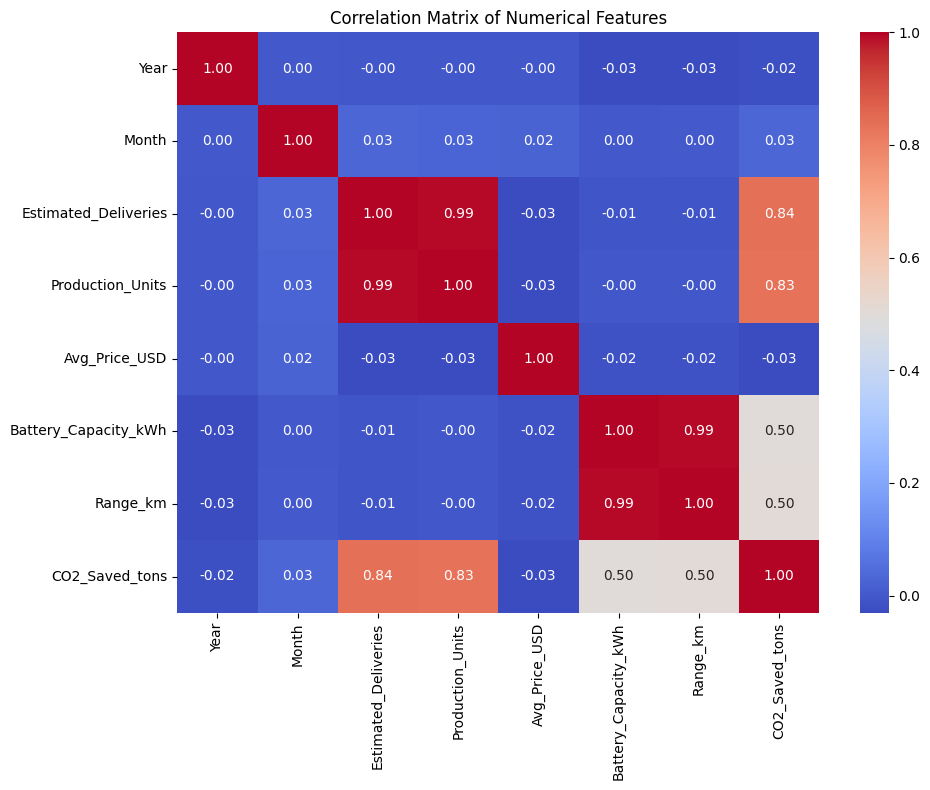

In [11]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

### Feature Engineering: Create a Date Column and Analyze Delivery vs. Production Differences

In [12]:
# Combined Year and Month to create a Date column for better time-based analysis
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Calculated the gap between Production Units and Estimated Deliveries
df['Production_Delivery_Diff'] = df['Production_Units'] - df['Estimated_Deliveries']

# Displayed the updated data to check the result
display(df[['Date', 'Estimated_Deliveries', 'Production_Units', 'Production_Delivery_Diff']].head())

,Date,Estimated_Deliveries,Production_Units,Production_Delivery_Diff
0,2023-05-01,17646,17922,276
1,2015-02-01,3797,4164,367
2,2019-01-01,8411,9189,778
3,2021-02-01,6555,7311,756
4,2016-12-01,12374,13537,1163


### Visualize Production vs. Delivery Difference Over Time

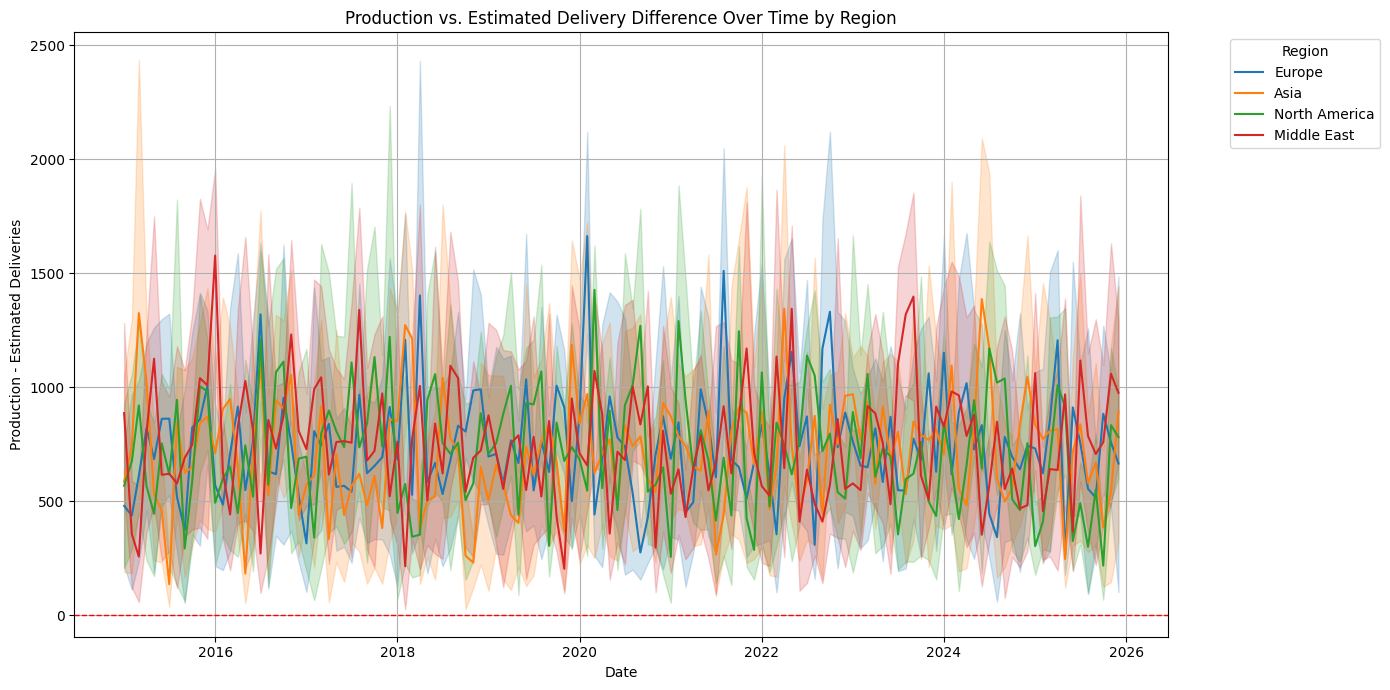

In [13]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='Date', y='Production_Delivery_Diff', hue='Region')
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Added a line at y=0 for reference
plt.title('Production vs. Estimated Delivery Difference Over Time by Region')
plt.xlabel('Date')
plt.ylabel('Production - Estimated Deliveries')
plt.grid(True)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Quantifying Production vs. Delivery Differences by Region

,mean,min,max
Region,,,
Asia,718.850000,0,3392
Europe,743.983333,1,2954
Middle East,751.551515,1,2600
North America,720.206061,1,3235


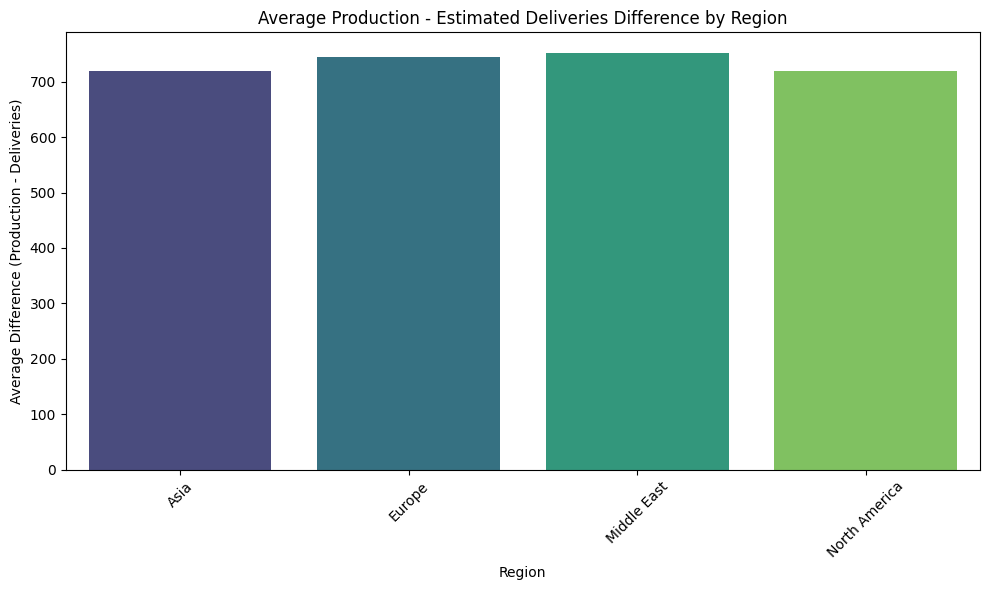

In [14]:
regional_diff_stats = df.groupby('Region')['Production_Delivery_Diff'].agg(['mean', 'min', 'max'])
display(regional_diff_stats)

plt.figure(figsize=(10, 6))
sns.barplot(data=regional_diff_stats.reset_index(), x='Region', y='mean', hue='Region', palette='viridis', legend=False)
plt.title('Average Production - Estimated Deliveries Difference by Region')
plt.xlabel('Region')
plt.ylabel('Average Difference (Production - Deliveries)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Average Price Analysis

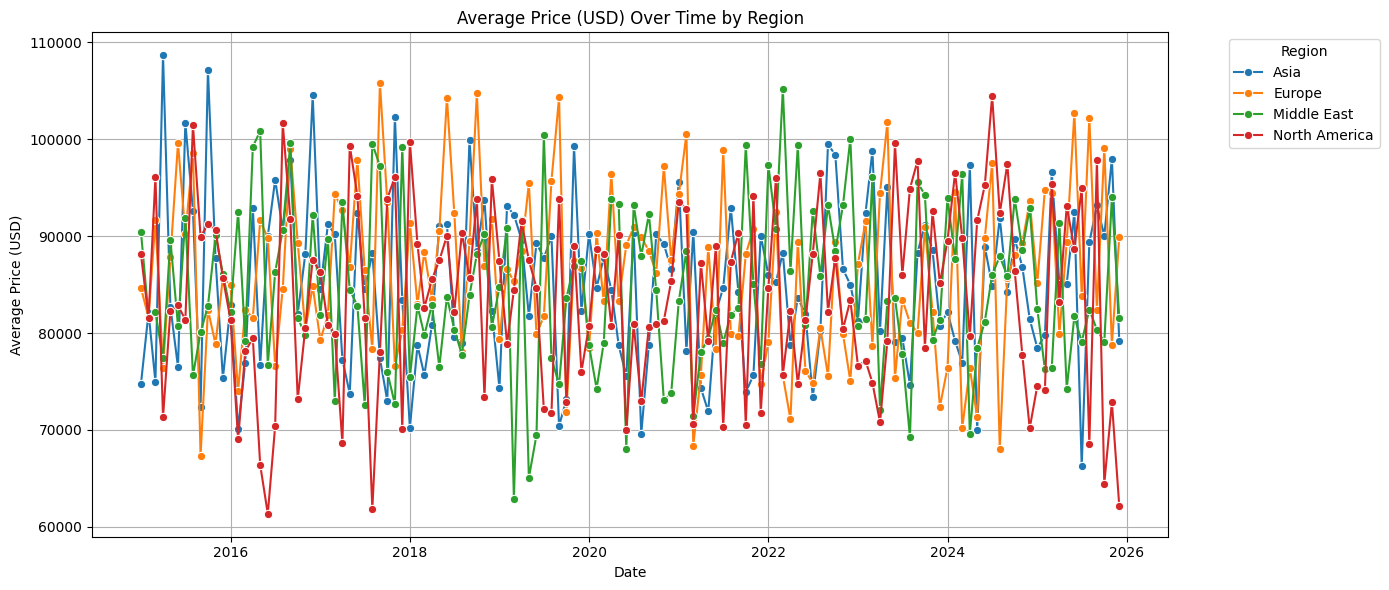

In [15]:
plt.figure(figsize=(14, 6))
price_over_time = df.groupby(['Date', 'Region'])['Avg_Price_USD'].mean().reset_index()
sns.lineplot(data=price_over_time, x='Date', y='Avg_Price_USD', hue='Region', marker='o')
plt.title('Average Price (USD) Over Time by Region')
plt.xlabel('Date')
plt.ylabel('Average Price (USD)')
plt.grid(True)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In this section, I analyzed the distribution of prices across different models and regions to identify any significant variations.

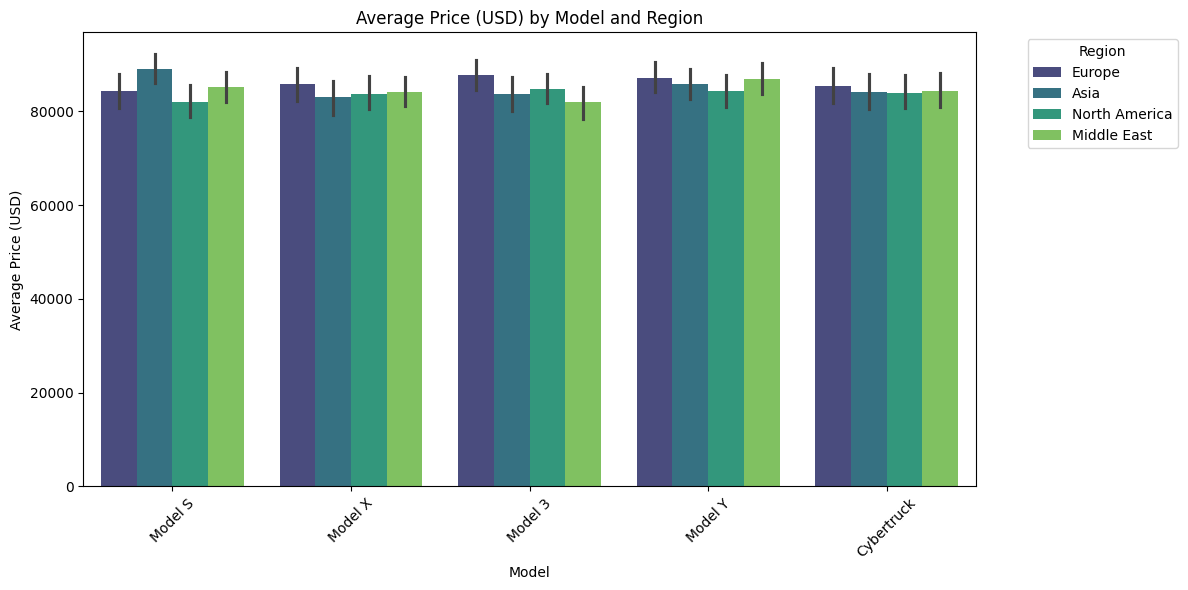

In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Model', y='Avg_Price_USD', hue='Region', palette='viridis')
plt.title('Average Price (USD) by Model and Region')
plt.xlabel('Model')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### CO2 Saved Analysis

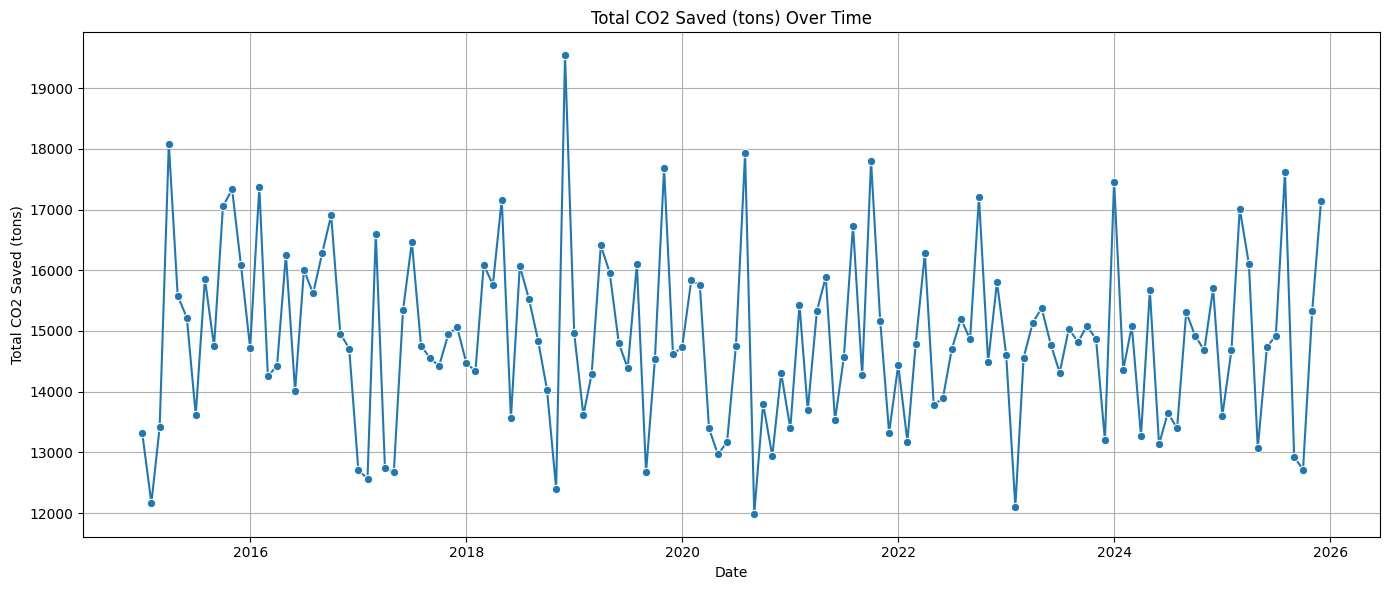

In [17]:
plt.figure(figsize=(14, 6))
co2_over_time = df.groupby('Date')['CO2_Saved_tons'].sum().reset_index()
sns.lineplot(data=co2_over_time, x='Date', y='CO2_Saved_tons', marker='o')
plt.title('Total CO2 Saved (tons) Over Time')
plt.xlabel('Date')
plt.ylabel('Total CO2 Saved (tons)')
plt.grid(True)
plt.tight_layout()
plt.show()

Here I plotted the distribution of CO2 saved by region and model, similar to how we analyzed deliveries and prices.

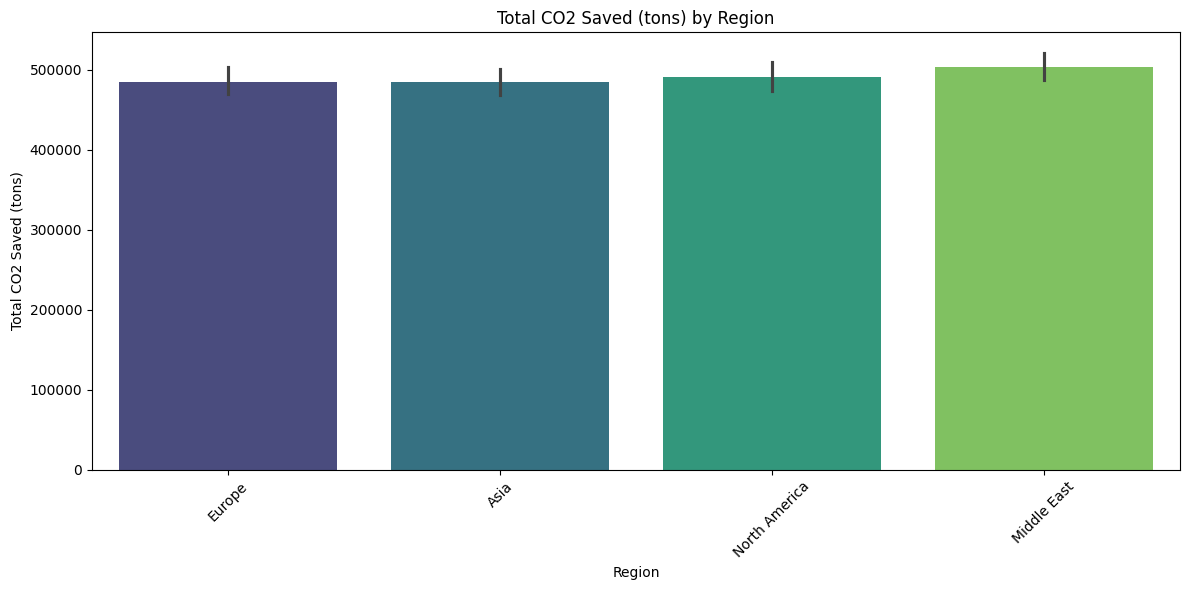

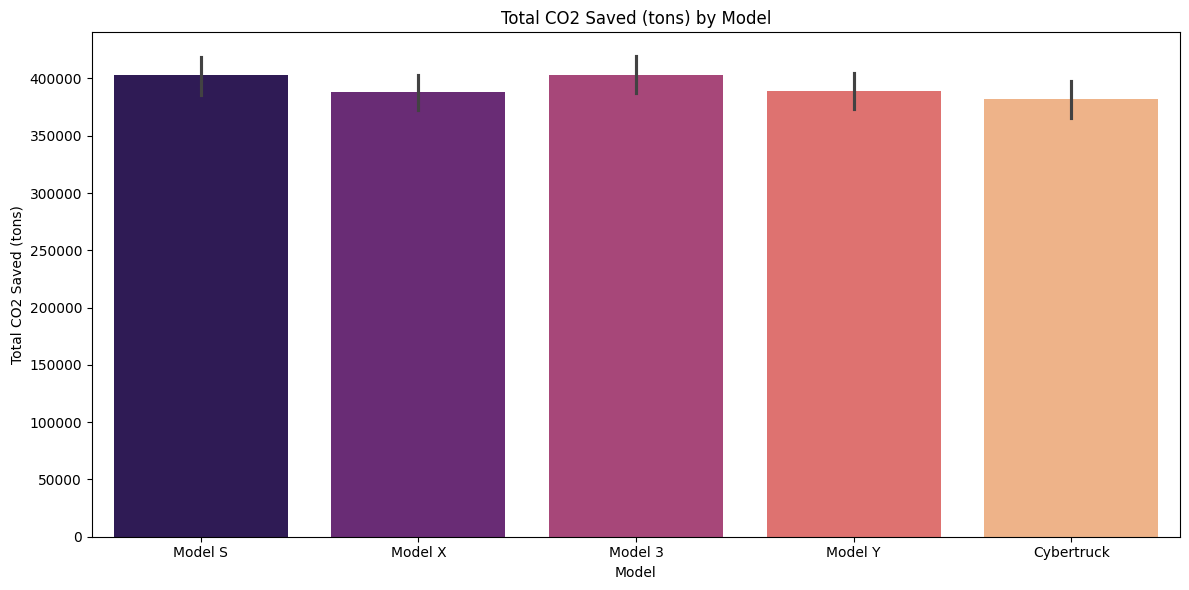

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Region', y='CO2_Saved_tons', estimator=sum, hue='Region', palette='viridis', legend=False)
plt.title('Total CO2 Saved (tons) by Region')
plt.xlabel('Region')
plt.ylabel('Total CO2 Saved (tons)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Model', y='CO2_Saved_tons', estimator=sum, hue='Model', palette='magma', legend=False)
plt.title('Total CO2 Saved (tons) by Model')
plt.xlabel('Model')
plt.ylabel('Total CO2 Saved (tons)')
plt.tight_layout()
plt.show()

### Feature Engineering for Time Series (Lagged Features and Rolling Statistics)

In [19]:
# Date, Region aur Model ke basis pe sort kiya — lag calculations sahi rahe iske liye
df_sorted = df.sort_values(by=['Region', 'Model', 'Date']).copy()

# Jin columns pe lagging aur rolling apply karni hai
target_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'CO2_Saved_tons']

# Lagged features banaye — 1 aur 3 mahine pehle ki values
for col in target_cols:
    df_sorted[f'{col}_lag1'] = df_sorted.groupby(['Region', 'Model'])[col].shift(1)
    df_sorted[f'{col}_lag3'] = df_sorted.groupby(['Region', 'Model'])[col].shift(3)

# 3-month rolling mean aur std nikali, min_periods=1 rakha taaki starting rows blank na rahe
for col in target_cols:
    df_sorted[f'{col}_rolling_mean3'] = df_sorted.groupby(['Region', 'Model'])[col].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    df_sorted[f'{col}_rolling_std3'] = df_sorted.groupby(['Region', 'Model'])[col].transform(lambda x: x.rolling(window=3, min_periods=1).std())

# Lagging se aayi NaN values ko 0 se fill kiya — baad mein better imputation consider karna
df_processed = df_sorted.fillna(0) # Or consider more sophisticated imputation strategies

# Naye features ka quick preview
print("DataFrame with new lagged and rolling features:")
display(df_processed[['Date', 'Region', 'Model'] + [col for col in df_processed.columns if '_lag' in col or '_rolling' in col]].head())

DataFrame with new lagged and rolling features:


,Date,Region,Model,Estimated_Deliveries_lag1,Estimated_Deliveries_lag3,Production_Units_lag1,Production_Units_lag3,Avg_Price_USD_lag1,Avg_Price_USD_lag3,CO2_Saved_tons_lag1,CO2_Saved_tons_lag3,Estimated_Deliveries_rolling_mean3,Estimated_Deliveries_rolling_std3,Production_Units_rolling_mean3,Production_Units_rolling_std3,Avg_Price_USD_rolling_mean3,Avg_Price_USD_rolling_std3,CO2_Saved_tons_rolling_mean3,CO2_Saved_tons_rolling_std3
1613,2015-01-01,Asia,Cybertruck,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,11325.000000,0.000000,11887.000000,0.000000,54449.080000,0.000000,575.880000,0.000000
2587,2015-02-01,Asia,Cybertruck,11325.0,0.0,11887.0,0.0,54449.08,0.00,575.88,0.00,12289.500000,1364.008981,13382.500000,2114.956383,71656.570000,24335.065732,717.370000,200.097077
1462,2015-03-01,Asia,Cybertruck,13254.0,0.0,14878.0,0.0,88864.06,0.00,858.86,0.00,11612.000000,1518.973008,12735.333333,1868.955412,69473.536667,17618.019631,776.213333,174.376127
1981,2015-04-01,Asia,Cybertruck,10257.0,11325.0,11441.0,11887.0,65107.47,54449.08,893.90,575.88,12910.666667,2499.746454,14090.000000,2355.999363,88886.053333,23789.587625,843.770000,59.137016
2011,2015-05-01,Asia,Cybertruck,15221.0,13254.0,15951.0,14878.0,112686.63,88864.06,778.55,858.86,10628.000000,4419.195289,11557.666667,4336.177272,95123.903333,26120.207194,700.976667,241.252442


### Data Preparation for Model Training (Target, Features, Categorical Encoding, Time-Series Split)

In [20]:
target = 'Estimated_Deliveries'
features = [col for col in df_processed.columns if col not in ['Year', 'Month', 'Date', target, 'Production_Delivery_Diff']]

X = df_processed[features]
y = df_processed[target]

# Region aur Model ko one-hot encoding mein convert kiya
categorical_features = ['Region', 'Model'] # Assuming these are still present and categorical
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Sirf numeric columns rakhe — encoding ke baad safety check
X = X.select_dtypes(include=['number'])

# X aur y ka index align kiya taaki rows mismatch na ho
y = y.loc[X.index]

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("First 5 rows of processed features (X):")
display(X.head())

# Time-series data hai toh chronological split kiya — random shuffle nahi
split_index = int(len(df_processed) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Shape of features (X): (2640, 21)
Shape of target (y): (2640,)
First 5 rows of processed features (X):


,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Estimated_Deliveries_lag1,Estimated_Deliveries_lag3,Production_Units_lag1,Production_Units_lag3,Avg_Price_USD_lag1,...,CO2_Saved_tons_lag1,CO2_Saved_tons_lag3,Estimated_Deliveries_rolling_mean3,Estimated_Deliveries_rolling_std3,Production_Units_rolling_mean3,Production_Units_rolling_std3,Avg_Price_USD_rolling_mean3,Avg_Price_USD_rolling_std3,CO2_Saved_tons_rolling_mean3,CO2_Saved_tons_rolling_std3
1613,11887,54449.08,60,339,575.88,0.0,0.0,0.0,0.0,0.00,...,0.00,0.00,11325.000000,0.000000,11887.000000,0.000000,54449.080000,0.000000,575.880000,0.000000
2587,14878,88864.06,75,432,858.86,11325.0,0.0,11887.0,0.0,54449.08,...,575.88,0.00,12289.500000,1364.008981,13382.500000,2114.956383,71656.570000,24335.065732,717.370000,200.097077
1462,11441,65107.47,100,581,893.90,13254.0,0.0,14878.0,0.0,88864.06,...,858.86,0.00,11612.000000,1518.973008,12735.333333,1868.955412,69473.536667,17618.019631,776.213333,174.376127
1981,15951,112686.63,60,341,778.55,10257.0,11325.0,11441.0,11887.0,65107.47,...,893.90,575.88,12910.666667,2499.746454,14090.000000,2355.999363,88886.053333,23789.587625,843.770000,59.137016
2011,7281,107577.61,75,448,430.48,15221.0,13254.0,15951.0,14878.0,112686.63,...,778.55,858.86,10628.000000,4419.195289,11557.666667,4336.177272,95123.903333,26120.207194,700.976667,241.252442



Training set size: 2112 samples
Testing set size: 528 samples


With our data prepped and split, ab seedha model training pe aate hain. Time-series data ke liye RandomForestRegressor ya GradientBoostingRegressor solid choice hai — phir hyperparameter tuning se aur optimize kar sakte hain.

### Exploring Other Regression Models: Linear, Ridge, and Lasso

Before RandomForest mein jaayein, pehle simple linear models se ek baseline set karte hain. Linear Regression, Ridge (L2), aur Lasso (L1) try karenge — isse samajh aayega ki complex models actually kitna extra value de rahe hain.

In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Dictionary to store model performance metrics
model_performance = {}

# --- Linear Regression ---
print("\nTraining Linear Regression model...")
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
print(f"Linear Regression MAE: {mae_linear:.2f}")
print(f"Linear Regression RMSE: {rmse_linear:.2f}")
model_performance['Linear Regression'] = {'MAE': mae_linear, 'RMSE': rmse_linear}

# -- Ridge Regression --
print("\nTraining Ridge Regression model...")
ridge_model = Ridge(random_state=42)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print(f"Ridge Regression MAE: {mae_ridge:.2f}")
print(f"Ridge Regression RMSE: {rmse_ridge:.2f}")
model_performance['Ridge Regression'] = {'MAE': mae_ridge, 'RMSE': rmse_ridge}

# -- Lasso Regression --
print("\nTraining Lasso Regression model...")
lasso_model = Lasso(random_state=42, max_iter=2000) # Increased max_iter for convergence
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
print(f"Lasso Regression MAE: {mae_lasso:.2f}")
print(f"Lasso Regression RMSE: {rmse_lasso:.2f}")
model_performance['Lasso Regression'] = {'MAE': mae_lasso, 'RMSE': rmse_lasso}



Training Linear Regression model...
Linear Regression MAE: 211.45
Linear Regression RMSE: 268.25

Training Ridge Regression model...
Ridge Regression MAE: 211.45
Ridge Regression RMSE: 268.25

Training Lasso Regression model...
Lasso Regression MAE: 211.43
Lasso Regression RMSE: 268.22


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.676e+07, tolerance: 3.297e+06
  model = cd_fast.enet_coordinate_descent(


### Comparison of Regression Models

Let's compile the performance metrics of all trained regression models — Linear, Ridge, Lasso, and RandomForest — into a single table so we can compare them side by side easily

### Model Training and Evaluation (RandomForestRegressor)

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Random Forest model initialize kiya, random_state fix kiya taaki results reproduce ho sake
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model.
print("Training the RandomForestRegressor...")
model.fit(X_train, y_train)
print("Training complete.")

y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Display feature importances
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 10 Feature Importances:")
display(feature_importances.head(10))

Training the RandomForestRegressor...
Training complete.

Model Evaluation:
Mean Absolute Error (MAE): 334.22
Root Mean Squared Error (RMSE): 442.60

Top 10 Feature Importances:


,0
Production_Units,0.989495
CO2_Saved_tons,0.001246
Estimated_Deliveries_rolling_std3,0.000854
Range_km,0.000701
Avg_Price_USD_lag3,0.000672
Avg_Price_USD,0.000603
Estimated_Deliveries_rolling_mean3,0.000579
CO2_Saved_tons_rolling_std3,0.000547
Avg_Price_USD_rolling_std3,0.000547
CO2_Saved_tons_lag1,0.000534


Model trained and evaluated — now the natural next step is hyperparameter tuning to squeeze out better performance, followed by a closer look at predictions through actual vs. predicted visualizations.

### Prediction Visualization: Actual vs. Predicted Deliveries

To see how well our model is actually doing, let's plot actual Estimated_Deliveries against y_pred on the test set over time — makes it easy to spot where predictions drift and what patterns the model might be missing.

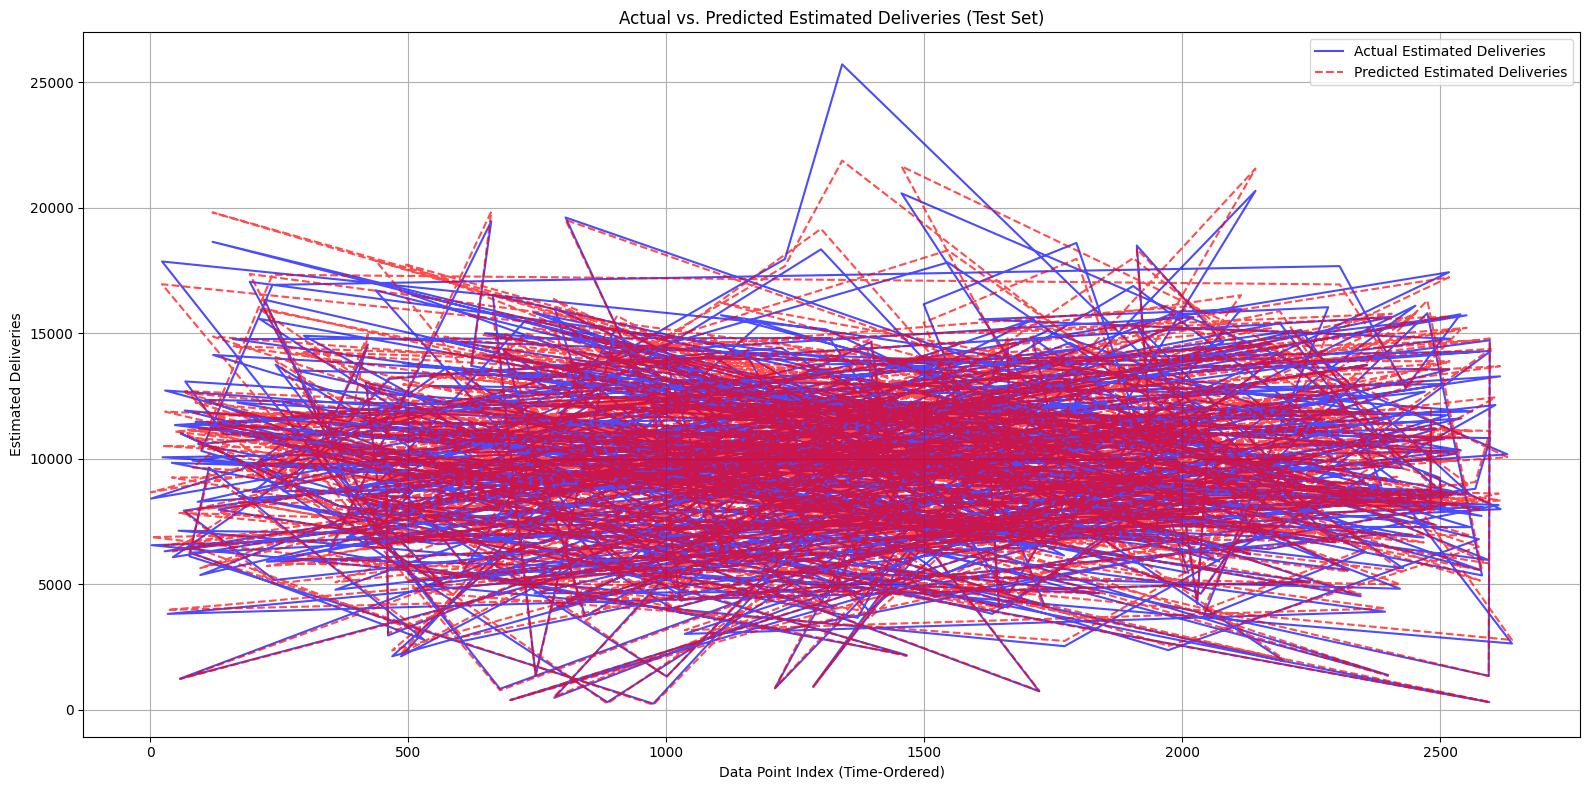

In [23]:
plt.figure(figsize=(16, 8))
plt.plot(y_test.index, y_test, label='Actual Estimated Deliveries', color='blue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicted Estimated Deliveries', color='red', alpha=0.7, linestyle='--')
plt.title('Actual vs. Predicted Estimated Deliveries (Test Set)')
plt.xlabel('Data Point Index (Time-Ordered)')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Hyperparameter Tuning

Now that we have a baseline, let's tune the RandomForestRegressor hyperparameters to push performance further. We'll use GridSearchCV to systematically find the best parameter combination — better accuracy and generalization ka shortcut yahi hai.

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# GridSearchCV setup — MAE minimize karna hai isliye neg_mean_absolute_error use kiya
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
                           param_grid=param_grid,
                           cv=3, # Using 3-fold cross-validation
                           scoring='neg_mean_absolute_error',
                           verbose=2, # progress track karne ke liye
                           n_jobs=-1) # saare cores use karo speed ke liye

print("Starting GridSearchCV for hyperparameter tuning...")
grid_search.fit(X_train, y_train)
print("GridSearchCV complete.")

best_params = grid_search.best_params_
best_score = -grid_search.best_score_

print(f"\nBest Hyperparameters: {best_params}")
print(f"Best Cross-Validation MAE: {best_score:.2f}")

# Train a new model
best_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

# Evaluate the best model
y_pred_tuned = best_model.predict(X_test)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"\nEvaluated Best Model on Test Set:")
print(f"Mean Absolute Error (MAE) with tuned model: {mae_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE) with tuned model: {rmse_tuned:.2f}")

Starting GridSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 324 candidates, totalling 972 fits
GridSearchCV complete.

Best Hyperparameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross-Validation MAE: 342.90

Evaluated Best Model on Test Set:
Mean Absolute Error (MAE) with tuned model: 332.65
Root Mean Squared Error (RMSE) with tuned model: 439.63


### Comparison of Model Performance (Initial vs. Tuned)

Let's quickly compare the initial RandomForestRegressor against the tuned one — see if all that GridSearch effort actually paid off.

In [28]:
print(f"Initial Model MAE: {mae:.2f}")
print(f"Initial Model RMSE: {rmse:.2f}")
print(f"\nTuned Model MAE: {mae_tuned:.2f}")
print(f"Tuned Model RMSE: {rmse_tuned:.2f}")

if mae_tuned < mae:
    print("\nHyperparameter tuning successfully reduced MAE!")
else:
    print("\nHyperparameter tuning did not significantly reduce MAE or slightly increased it.")

Initial Model MAE: 334.22
Initial Model RMSE: 442.60

Tuned Model MAE: 332.65
Tuned Model RMSE: 439.63

Hyperparameter tuning successfully reduced MAE!


### Time Series Forecasting: Exploring ARIMA

Since our data is time-series, let's also try ARIMA — a solid forecasting model that handles trends and seasonal patterns well.
Before fitting ARIMA, the series needs to be stationary — meaning its mean and variance stay consistent over time. If not, differencing fixes that. We'll first aggregate Estimated_Deliveries into a single univariate series, check stationarity, then apply ARIMA.

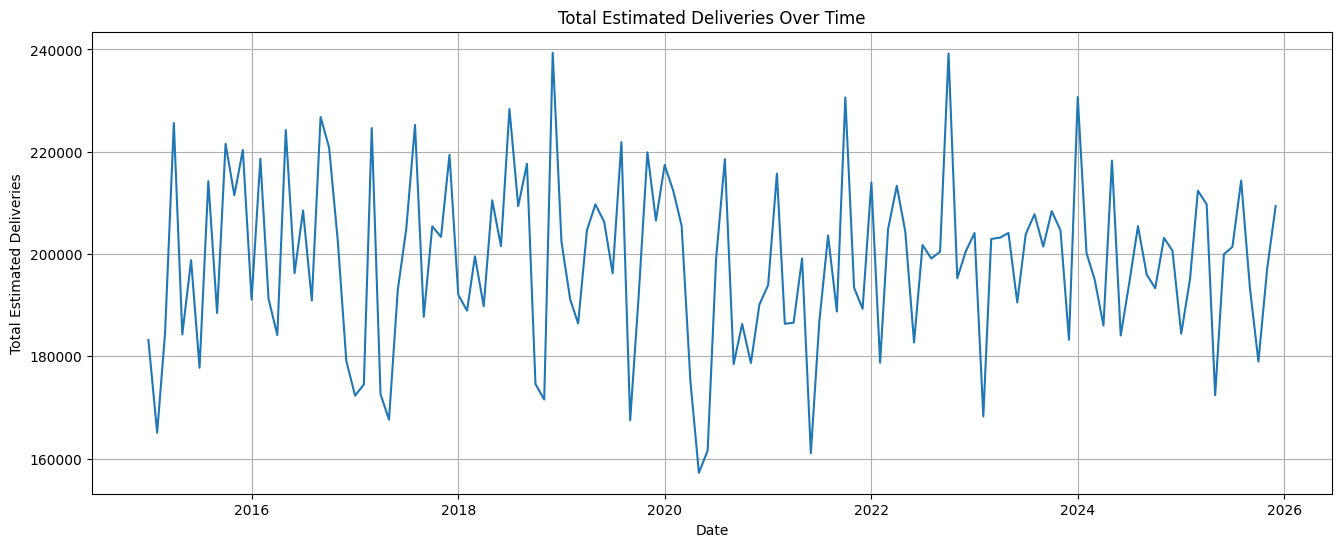

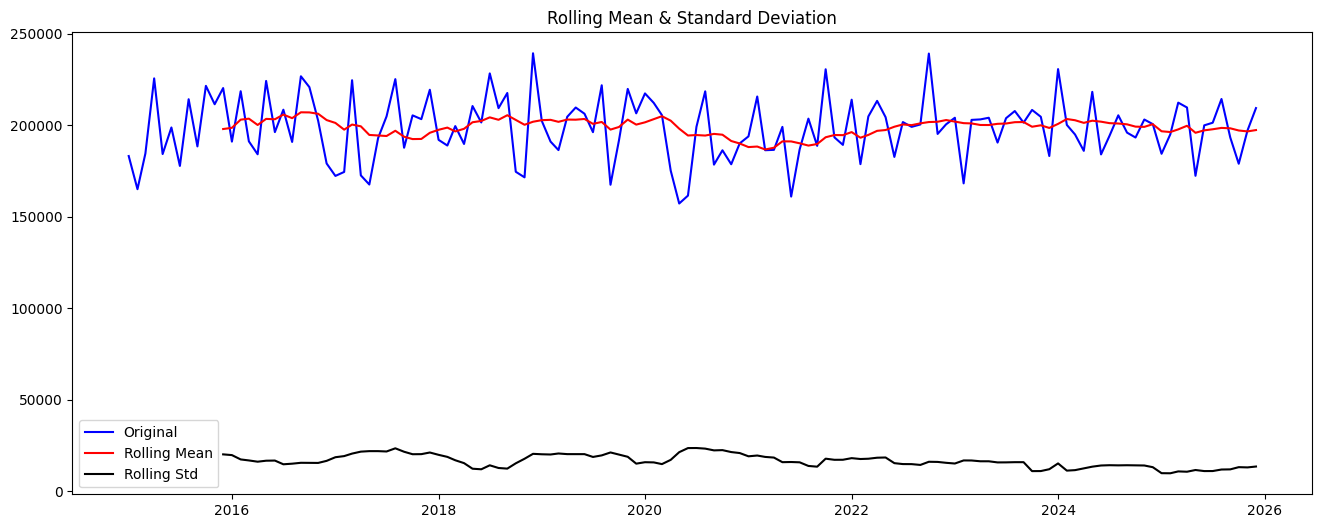

Results of Dickey-Fuller Test:
Test Statistic                -8.880990e+00
p-value                        1.318140e-14
#Lags Used                     1.000000e+00
Number of Observations Used    1.300000e+02
Critical Value (1%)           -3.481682e+00
Critical Value (5%)           -2.884042e+00
Critical Value (10%)          -2.578770e+00
dtype: float64


In [30]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Date ko index set kiya aur monthly level pe deliveries aggregate ki
df_time_series = df_processed.set_index('Date').sort_index()
total_deliveries_ts = df_time_series['Estimated_Deliveries'].resample('MS').sum() # 'MS' for Month Start frequency

# Time series plot — trends aur seasonality visually check karne ke liye
plt.figure(figsize=(16, 6))
plt.plot(total_deliveries_ts)
plt.title('Total Estimated Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Total Estimated Deliveries')
plt.grid(True)
plt.show()

# Stationarity check function — rolling stats + Augmented Dickey-Fuller test
def check_stationarity(timeseries):
    # Determing rolling statistics
    rolmean = timeseries.rolling(window=12).mean()
    rolstd = timeseries.rolling(window=12).std()

    # Original series ke saath rolling stats plot kiye
    plt.figure(figsize=(16, 6))
    plt.plot(timeseries, color='blue', label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label='Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()

    # Dickey-Fuller test — p-value < 0.05 ho toh series stationary hai
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
       dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

check_stationarity(total_deliveries_ts)

### Determining ARIMA Orders (p, q) with ACF and PACF Plots
Since our series is stationary, now we need to figure out the right p and q values for ARIMA — ACF and PACF plots help us do exactly that.

-  ACF plot — picks q (MA order), shows how the series correlates with its own past values
-  PACF plot — picks p (AR order), same idea but removes the influence of in-between lags first

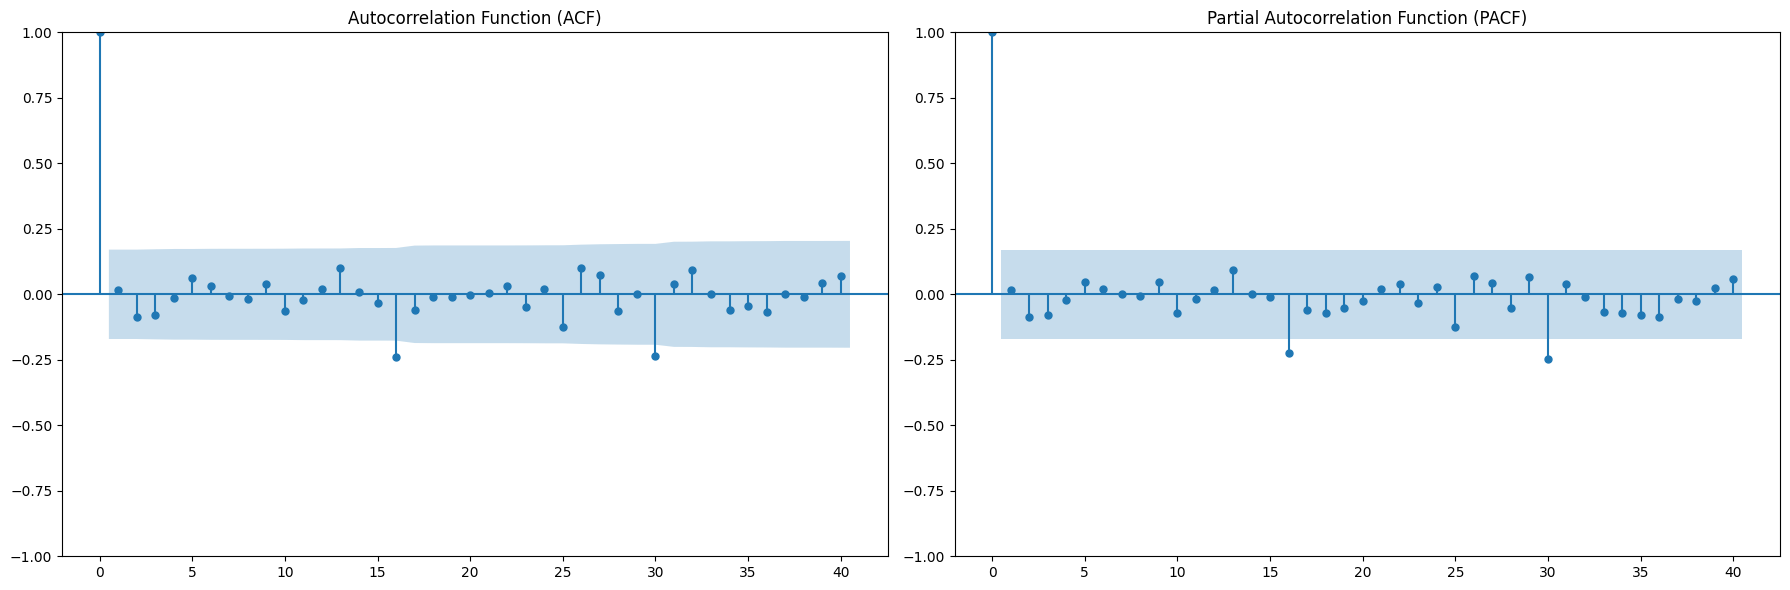

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_acf(total_deliveries_ts, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(total_deliveries_ts, lags=40, ax=axes[1], method='ywm') # 'ywm' method for PACF
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

### Fitting the ARIMA Model

Based on ACF and PACF analysis, stationarity confirmed (d=0), so we'll start with ARIMA(1,0,1) — p=1 from the PACF spike at lag 1, q=1 from the ACF spike at lag 1. If results aren't great, we can try other combinations or add seasonal components.

In [32]:
# Chronological split — last 20% as test set
train_size = int(len(total_deliveries_ts) * 0.8)
arima_train, arima_test = total_deliveries_ts[0:train_size], total_deliveries_ts[train_size:]

print(f"ARIMA training set size: {len(arima_train)}")
print(f"ARIMA test set size: {len(arima_test)}")

# Fitting ARIMA(1,0,1) — AR(1), no differencing, MA(1)
model_arima = ARIMA(arima_train, order=(1,0,1))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())


ARIMA training set size: 105
ARIMA test set size: 27
                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  105
Model:                   ARIMA(1, 0, 1)   Log Likelihood               -1175.024
Date:                  Sat, 13 Jun 2026   AIC                           2358.049
Time:                          18:35:03   BIC                           2368.664
Sample:                      01-01-2015   HQIC                          2362.350
                           - 09-01-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.983e+05    653.328    303.544      0.000    1.97e+05       2e+05
ar.L1          0.9367      0.043     21.563      0.000       0

### Forecasting with ARIMA and Evaluation

Now that our ARIMA model is fitted, let's use it to forecast future `Estimated_Deliveries` on our test set. We'll then evaluate its performance using metrics like MAE and RMSE, and visualize the forecasts against the actual values.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)



ARIMA Model Evaluation:
Mean Absolute Error (MAE) for ARIMA: 9884.12
Root Mean Squared Error (RMSE) for ARIMA: 12616.62


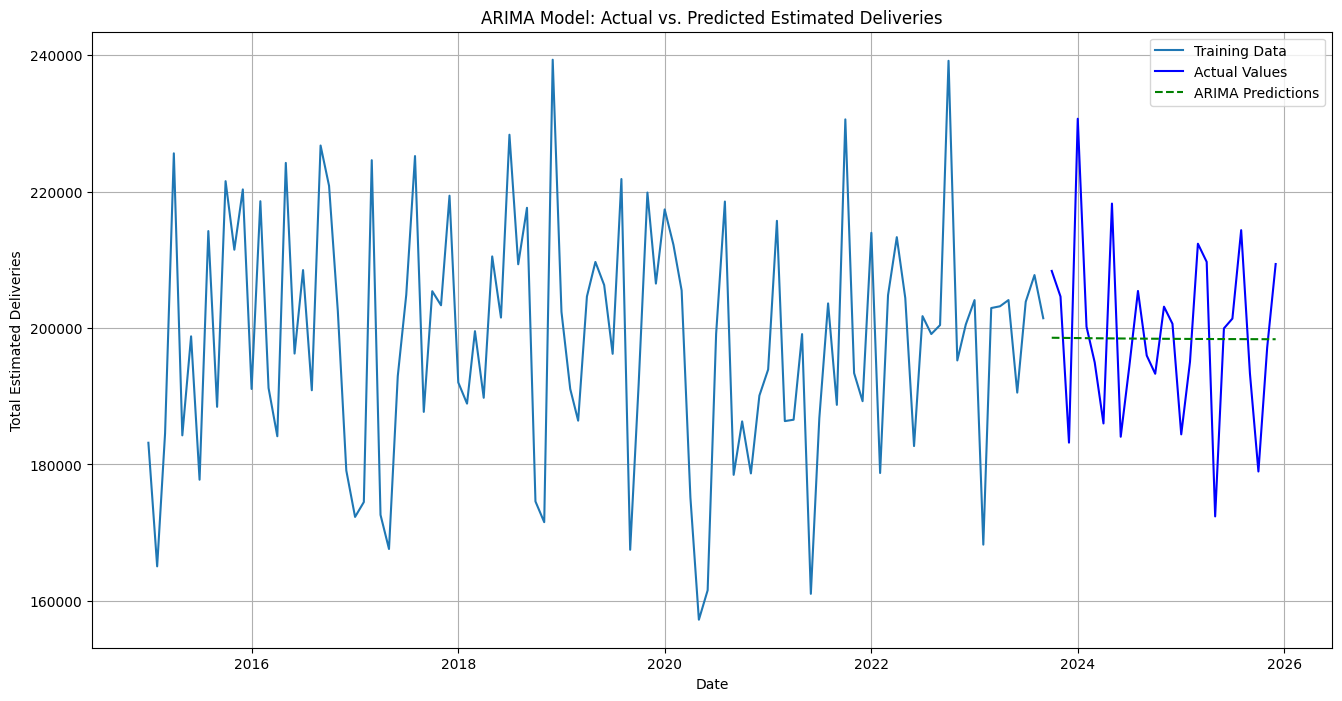

In [34]:
# Make predictions on the test set
start = len(arima_train)
end = len(total_deliveries_ts) - 1
predictions_arima = model_arima_fit.predict(start=start, end=end, typ='levels')
predictions_arima.index = arima_test.index

# Evaluate ARIMA model
mae_arima = mean_absolute_error(arima_test, predictions_arima)
rmse_arima = np.sqrt(mean_squared_error(arima_test, predictions_arima))

print(f"\nARIMA Model Evaluation:")
print(f"Mean Absolute Error (MAE) for ARIMA: {mae_arima:.2f}")
print(f"Root Mean Squared Error (RMSE) for ARIMA: {rmse_arima:.2f}")

# Plot actual vs. predicted for ARIMA
plt.figure(figsize=(16, 8))
plt.plot(arima_train.index, arima_train, label='Training Data')
plt.plot(arima_test.index, arima_test, label='Actual Values', color='blue')
plt.plot(predictions_arima.index, predictions_arima, label='ARIMA Predictions', color='green', linestyle='--')
plt.title('ARIMA Model: Actual vs. Predicted Estimated Deliveries')
plt.xlabel('Date')
plt.ylabel('Total Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.show()

### Time Series Forecasting: Introducing SARIMA (Seasonal ARIMA)

ARIMA(1,0,1) couldn't capture the seasonal patterns in our data, so we're stepping up to SARIMA — it extends ARIMA by adding seasonal terms, making it much better suited for recurring patterns.
SARIMA is written as SARIMA(p,d,q)(P,D,Q)m where:

-  (p,d,q) — the usual non-seasonal AR, I, MA orders
-  (P,D,Q) — same but for the seasonal component
-  m — seasonal period length (12 for monthly data)

Since our series is already stationary, d=0 stays. We'll revisit ACF/PACF plots — possibly after seasonal differencing — to pin down the right P, D, Q values.

### Determining SARIMA Orders with Seasonal ACF and PACF

To find the right seasonal orders (P, D, Q), we look at ACF and PACF at seasonal lags. Since our series is already stationary (d=0), we'll apply seasonal differencing (D=1) to remove any seasonal trends — then re-examine the plots to decide P and Q

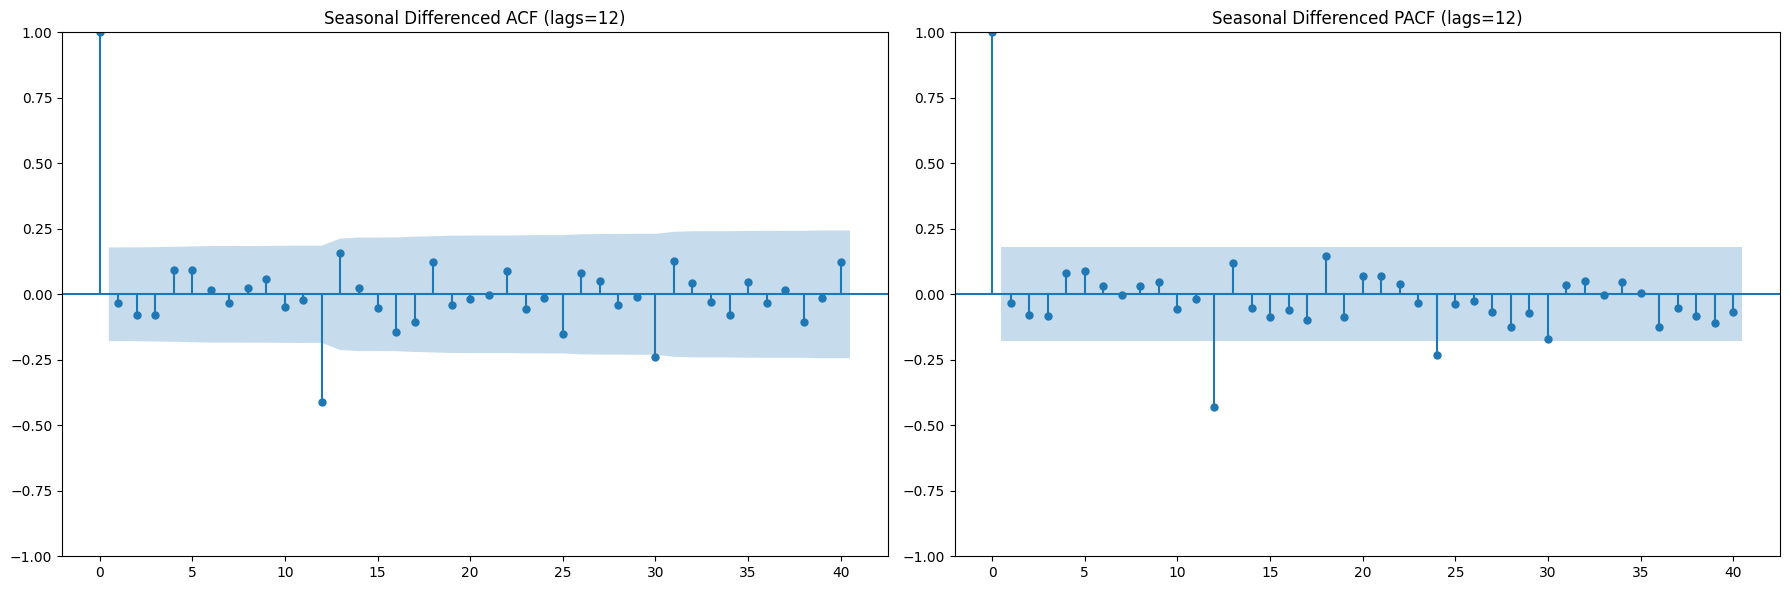

In [36]:
# Seasonal differencing applied — lag 12 pe diff liya monthly patterns remove karne ke liye
total_deliveries_ts_seasonal_diff = total_deliveries_ts.diff(12).dropna()

# ACF aur PACF plots — seasonal orders P aur Q identify karne ke liye
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_acf(total_deliveries_ts_seasonal_diff, lags=40, ax=axes[0])
axes[0].set_title('Seasonal Differenced ACF (lags=12)')

plot_pacf(total_deliveries_ts_seasonal_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Seasonal Differenced PACF (lags=12)')

plt.tight_layout()
plt.show()

### Fitting the SARIMA Model

From the seasonal ACF/PACF plots — lag 12 spike in ACF points to seasonal MA(1) (Q=1), PACF spike suggests seasonal AR(1) (P=1), and seasonal differencing gives us D=1.
Starting with SARIMA(1,0,1)(1,1,1)[12] — non-seasonal orders kept small, seasonal components will handle the rest. We'll see how it performs.

In [35]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Same split point as before for consistency
sarima_train, sarima_test = total_deliveries_ts[0:train_size], total_deliveries_ts[train_size:]

print(f"SARIMA training set size: {len(sarima_train)}")
print(f"SARIMA test set size: {len(sarima_test)}")

# SARIMA(1,0,1)(1,1,1)[12] — monthly seasonality, s=12
model_sarima = SARIMAX(sarima_train,
                       order=(1, 0, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

model_sarima_fit = model_sarima.fit(disp=False) # convergence messages suppress kiye

print(model_sarima_fit.summary())


SARIMA training set size: 105
SARIMA test set size: 27
                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  105
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -897.053
Date:                            Sat, 13 Jun 2026   AIC                           1804.105
Time:                                    18:46:21   BIC                           1815.953
Sample:                                01-01-2015   HQIC                          1808.852
                                     - 09-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9209      0.025     36.538      0.000     

### Forecasting with SARIMA and Evaluation

SARIMA model fit ho gaya — ab test set pe forecasts generate karte hain, MAE and RMSE se evaluate karte hain, aur actual vs predicted plot karte hain to see if it handles seasonality better than plain ARIMA.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)



SARIMA Model Evaluation:
Mean Absolute Error (MAE) for SARIMA: 13070.37
Root Mean Squared Error (RMSE) for SARIMA: 17018.14


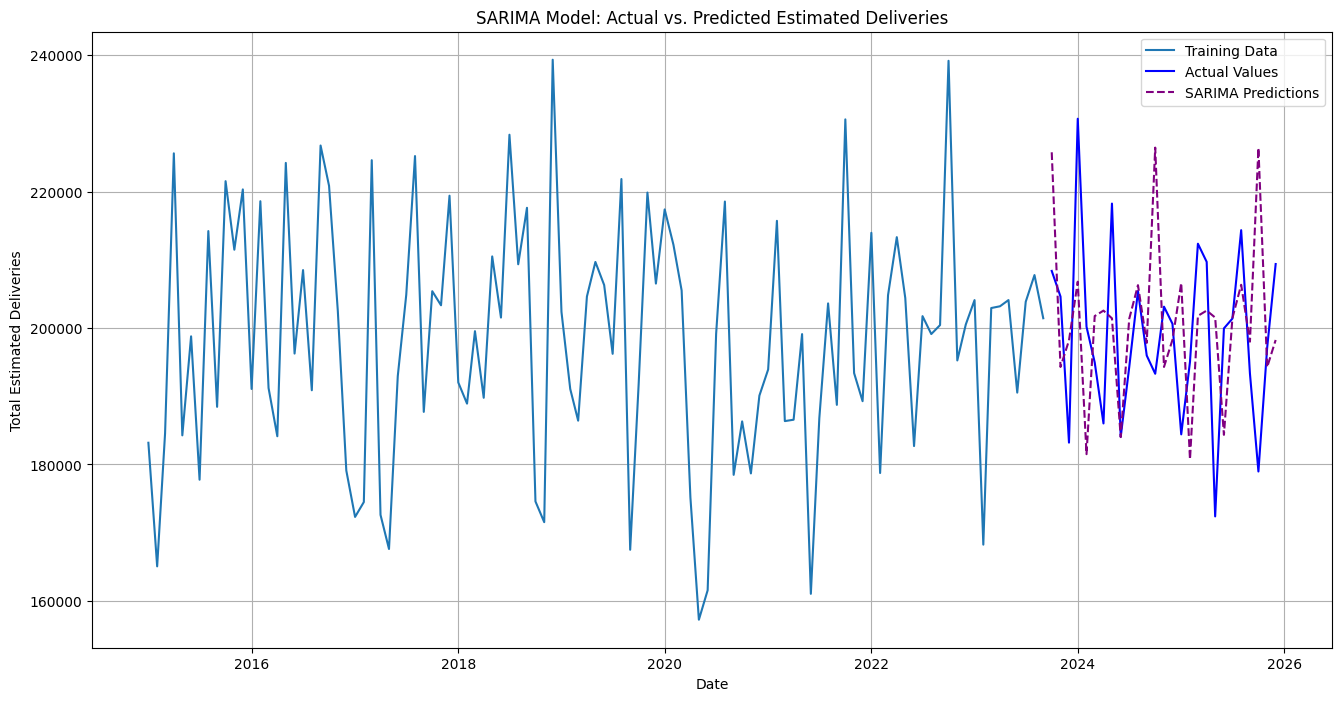

In [37]:
# Make predictions on the test set
sarima_start = len(sarima_train)
sarima_end = len(total_deliveries_ts) - 1
predictions_sarima = model_sarima_fit.predict(start=sarima_start, end=sarima_end, typ='levels')
predictions_sarima.index = sarima_test.index

# Evaluate SARIMA model
mae_sarima = mean_absolute_error(sarima_test, predictions_sarima)
rmse_sarima = np.sqrt(mean_squared_error(sarima_test, predictions_sarima))

print(f"\nSARIMA Model Evaluation:")
print(f"Mean Absolute Error (MAE) for SARIMA: {mae_sarima:.2f}")
print(f"Root Mean Squared Error (RMSE) for SARIMA: {rmse_sarima:.2f}")

# Plot actual vs. predicted for SARIMA
plt.figure(figsize=(16, 8))
plt.plot(sarima_train.index, sarima_train, label='Training Data')
plt.plot(sarima_test.index, sarima_test, label='Actual Values', color='blue')
plt.plot(predictions_sarima.index, predictions_sarima, label='SARIMA Predictions', color='purple', linestyle='--')
plt.title('SARIMA Model: Actual vs. Predicted Estimated Deliveries')
plt.xlabel('Date')
plt.ylabel('Total Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.show()

These newly engineered features provide historical context, which is crucial for building predictive models, especially for time series forecasting. The next steps will involve preparing this data for model training, including splitting into training and testing sets, and then selecting and training a regression model.

# Final Project Report: Tesla Deliveries Prediction

## 1. Project Goal

The goal of this project was to build a complete ML pipeline to analyze and predict Tesla’s estimated deliveries using real-world data from 2015 to 2025. The dataset included features like production units, average price, region, and car model.

## 2. Data Loading & Initial Inspection

I started by loading the CSV file into a pandas DataFrame. After checking with df.info() and df.describe(), I found that the data had no missing values and no duplicate rows — so no cleaning was needed.

## 3. Exploratory Data Analysis (EDA)

-  I plotted delivery and production trends over the years, broken down by month, to spot any patterns.
-  Bar charts showed which regions and car models had the highest deliveries.
-  A correlation heatmap revealed that Production_Units and CO2_Saved_tons are strongly linked to Estimated_Deliveries.
-  I also checked how average price changed over time across different regions and models.

## 4. Feature Engineering

-  Combined Year and Month columns to create a proper Date column for time series work.
-  Created a new column Production_Delivery_Diff to see the gap between production and actual deliveries.
-  Added lag features (1-month and 3-month) and rolling mean/std features for key columns to help models learn from past trends.

## 5. Data Preparation

-	 Target variable: Estimated_Deliveries
-  Region and Model columns were one-hot encoded.
-  Data was split chronologically — 80% for training, 20% for testing — to avoid data leakage.

## 6. Regression Models

Linear, Ridge and Lasso Regression

I first trained three basic regression models as a baseline:

| Model                       | MAE     | RMSE    |
| :-------------------------- | :------ | :------ |
| Lasso Regression            | 211.43  | 268.22  |
| Ridge Regression            | 211.45  | 268.25  |
| Linear Regression           | 211.45  | 268.25  |
All three performed similarly and gave good results.
##  Random Forest Regressor

| Model                       | MAE     | RMSE    |
| :-------------------------- | :------ | :------ |
| RandomForestRegressor (Tuned)| 332.65  | 439.63  |
| RandomForestRegressor (Initial)| 334.22  | 442.60  |

After hyperparameter tuning using GridSearchCV, the model improved slightly. Production_Units turned out to be the most important feature by far.

Interestingly, the simpler linear models actually performed better than RandomForest here — which suggests the relationship between features and deliveries is mostly linear.

## 7. Time Series Forecasting: ARIMA & SARIMA

-  The delivery data was aggregated monthly and checked for stationarity using the Augmented Dickey-Fuller test — it was already stationary.
-  ARIMA(1,0,1): MAE = 9884, RMSE = 12616 — predictions were mostly flat and not useful.
-  SARIMA(1,0,1)(1,1,1)[12]: MAE = 13070, RMSE = 17018 — seasonal patterns were captured better visually but metrics were worse.

## 8. Overall Conclusion

From this project, I found that feature engineering played a huge role in model performance. The linear models surprisingly outperformed RandomForest on this dataset. ARIMA and SARIMA struggled compared to regression models because they don’t use extra features like production units. Overall, this project gave me hands-on experience with a real end-to-end ML pipeline.